In [5]:
import polars as pl
import seaborn as sns
import polars.selectors as cs

trn = pl.read_csv("data/train.csv")

# Shape of Data

In [2]:
trn.shape

(90615, 10)

In [3]:
trn.columns

['id',
 'Sex',
 'Length',
 'Diameter',
 'Height',
 'Whole weight',
 'Whole weight.1',
 'Whole weight.2',
 'Shell weight',
 'Rings']

In [4]:
trn.head()

id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
i64,str,f64,f64,f64,f64,f64,f64,f64,i64
0,"""F""",0.55,0.43,0.15,0.7715,0.3285,0.1465,0.24,11
1,"""F""",0.63,0.49,0.145,1.13,0.458,0.2765,0.32,11
2,"""I""",0.16,0.11,0.025,0.021,0.0055,0.003,0.005,6
3,"""M""",0.595,0.475,0.15,0.9145,0.3755,0.2055,0.25,10
4,"""I""",0.555,0.425,0.13,0.782,0.3695,0.16,0.1975,9


# Target Column

<Axes: xlabel='Rings', ylabel='Count'>

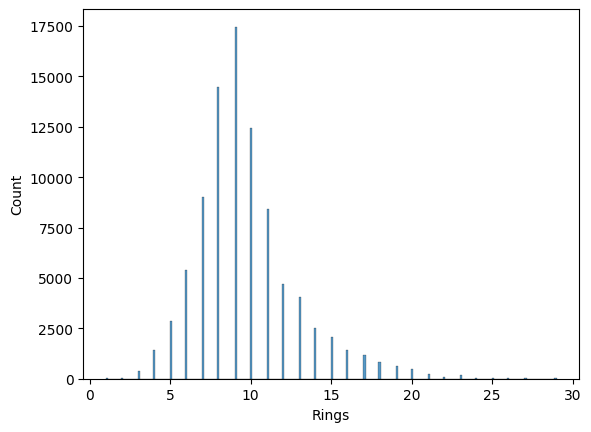

In [6]:
sns.histplot(trn, x="Rings")

<Axes: xlabel='Rings', ylabel='Count'>

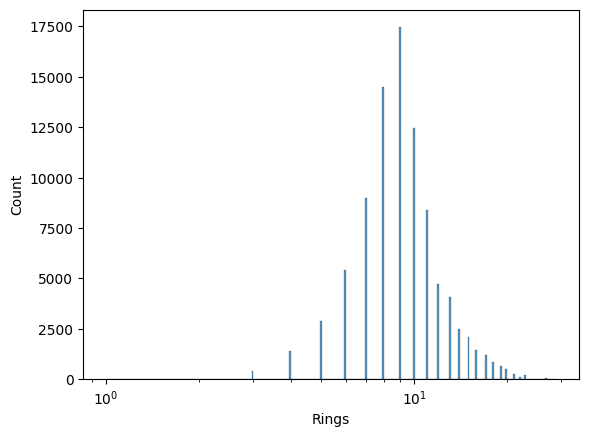

In [7]:
sns.histplot(trn, x="Rings", log_scale=True)


# Numerical Cols

In [8]:
X_num = trn.select(cs.by_dtype(pl.NUMERIC_DTYPES))

In [12]:
X_num_long = X_num.melt(id_vars="id")

#making histograms for all of the numeric vars
X_num_long.head()

id,variable,value
i64,str,f64
0,"""Length""",0.55
1,"""Length""",0.63
2,"""Length""",0.16
3,"""Length""",0.595
4,"""Length""",0.555


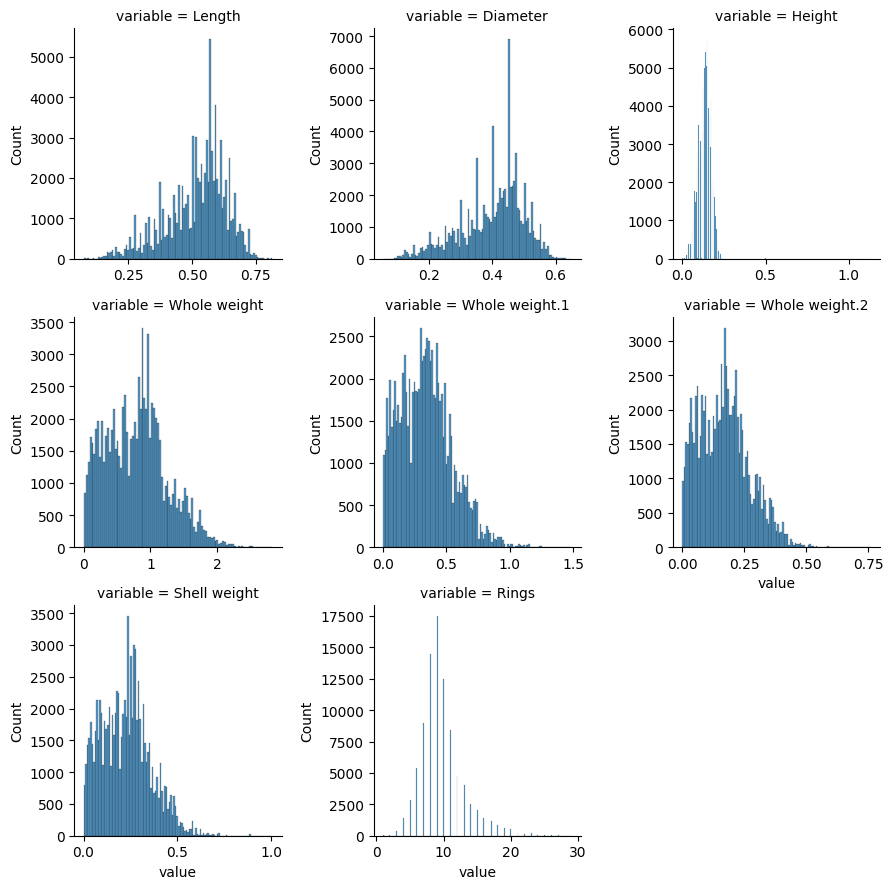

In [22]:
g = sns.FacetGrid(X_num_long.to_pandas(), col="variable", col_wrap=3, sharex=False, sharey=False)
g.map_dataframe(sns.histplot, x="value")

Ok, so I probably want to Box-Cox transform these variables.

I may also want to interact length x width x height to get a volume parameter, which is probably associated with age.

Also, from the California Dept of Fish and Wildlife -- "abalone grow nearly one inch per year for the first few years and much more slowly after that." So there's probably a spline or discontinuity. Possibly explore this more

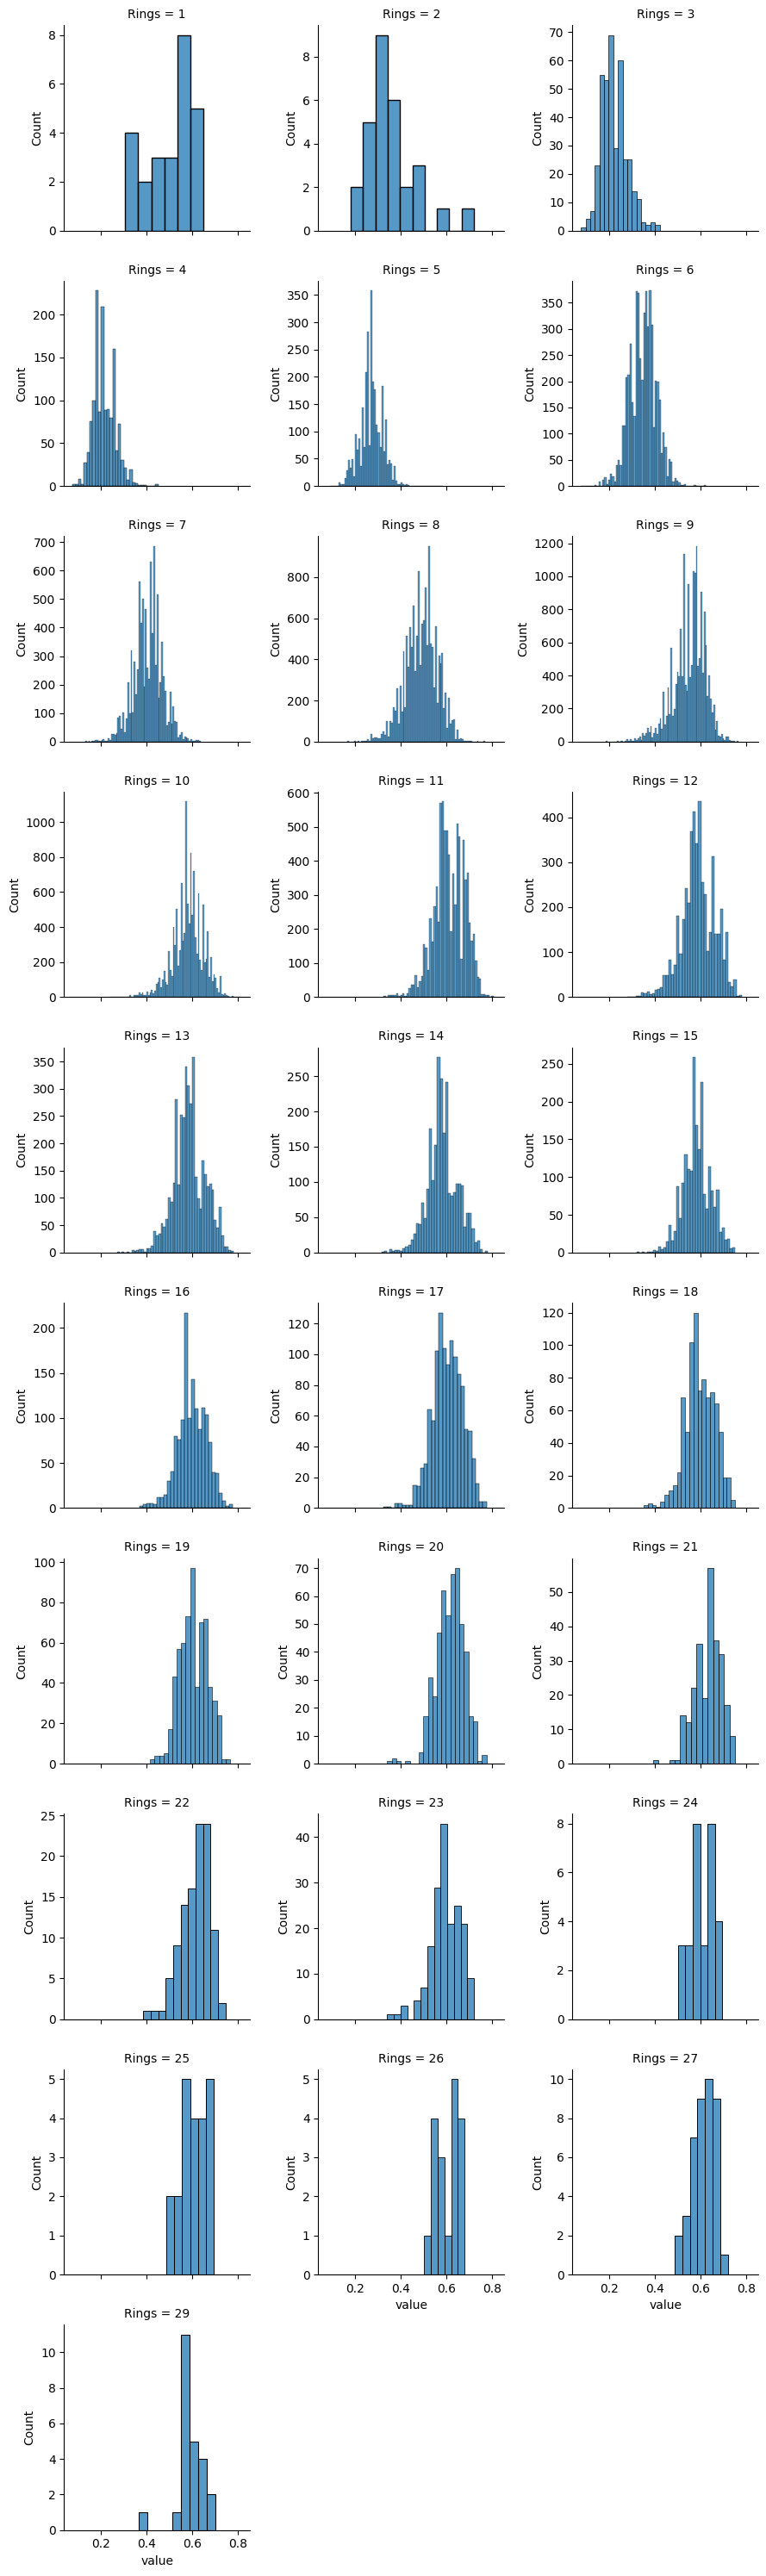

In [29]:
len_rings = trn.select(["Length", "Rings"])
len_rings_long = len_rings.melt(id_vars="Rings")

g2 = sns.FacetGrid(len_rings_long.to_pandas(), col="Rings", col_wrap=3, sharex=True, sharey=False)
g2.map_dataframe(sns.histplot, x="value")

ok so maybe we don't need a spline here...

What if we wanted to check out sex by rings

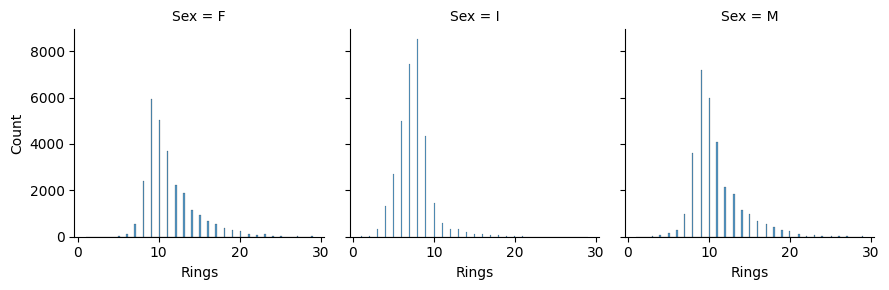

In [30]:
g3 = sns.FacetGrid(trn.to_pandas(), col="Sex")
g3.map_dataframe(sns.histplot, x="Rings")

So we see the same basic pattern for males and females, but I's tend to have fewer rings -- so that's something to check out as well.

Sex might also be associated with length

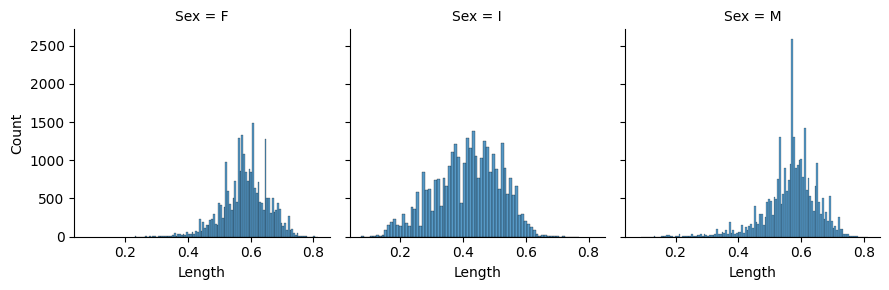

In [31]:
g4 = sns.FacetGrid(trn.to_pandas(), col="Sex")
g4.map_dataframe(sns.histplot, x="Length")


what about the correlation among numerical predictors?

In [32]:
X_num.corr()

id,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
f64,f64,f64,f64,f64,f64,f64,f64,f64
1.0,0.004724,0.00429,0.005916,0.005228,0.004203,0.004878,0.005887,0.000938
0.004724,1.0,0.989732,0.916094,0.931449,0.909609,0.913134,0.911073,0.623786
0.00429,0.989732,1.0,0.919618,0.933848,0.908466,0.914668,0.917871,0.636832
0.005916,0.916094,0.919618,1.0,0.902344,0.861769,0.886132,0.904019,0.665772
0.005228,0.931449,0.933848,0.902344,1.0,0.971249,0.974319,0.964201,0.617274
0.004203,0.909609,0.908466,0.861769,0.971249,1.0,0.949227,0.9118,0.515067
0.004878,0.913134,0.914668,0.886132,0.974319,0.949227,1.0,0.937069,0.588954
0.005887,0.911073,0.917871,0.904019,0.964201,0.9118,0.937069,1.0,0.694766
0.000938,0.623786,0.636832,0.665772,0.617274,0.515067,0.588954,0.694766,1.0


ok, so these all measure the same thing basically. So I probably want to just extract 1 factor/component and then use that in the model.

# Notes

- Possibly want to log scale my y before fitting